<a href="https://colab.research.google.com/github/samreenfathima18/guvi-project3/blob/main/project_3fitbit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fitbit : Calorie Burn Prediction & Workout Pattern Clustering Using Fitbit Data**

In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv('/content/drive/MyDrive/Fitbit_dataset.csv')

In [3]:
df.shape

(14102, 19)

In [4]:
df

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8


In [6]:
df.shape

(14102, 18)

In [7]:
df.isna().sum() # no null values

,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Workout_Type,0
Fat_Percentage,0


In [8]:
df.duplicated().sum() # no duplicates

np.int64(0)

**Supervised Learning: Calorie Burn Prediction (Regression)**

**Data Preprocessing:**


In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Fitbit_dataset.csv')

# Drop indexing artifacts safely if they exist in the raw file
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Separate Features and Target
X = df.drop(columns=['Calories_Burned (kcal)'], errors='ignore')
y = df['Calories_Burned (kcal)']

# 3. Outlier Capping (IQR Method) to prevent model distortion
def cap_outliers_iqr(dataframe, columns):
    df_capped = dataframe.copy()
    for col in columns:
        if col in df_capped.columns and df_capped[col].dtype in ['int64', 'float64']:
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df_capped[col] = np.clip(df_capped[col], lower_bound, upper_bound)
    return df_capped

# Specify continuous numerical columns for outlier tracking
num_cols = ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage',
            'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
            'Water_Intake (liters)', 'Workout_Frequency (days/week)']

X_capped = cap_outliers_iqr(X, num_cols)

# 4. Define Preprocessing Columns
cat_cols = ['Gender', 'Workout_Type', 'Experience_Level']

# 5. Split into Train and Test sets (80/20 Split)
X_train, X_test, y_train, y_test = train_test_split(X_capped, y, test_size=0.2, random_state=42)

# 6. Build Sklearn Transformers
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print("Data preprocessing structures generated successfully.")
print(f"Training features shape: {X_train.shape} | Testing features shape: {X_test.shape}")


Data preprocessing structures generated successfully.
Training features shape: (11281, 17) | Testing features shape: (2821, 17)


**Model Training & Evaluation:**

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression  # Added LinearRegression here
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Initialize the algorithms (now including Linear Regression)
models = {
    "Linear Regression": LinearRegression(),  # Added to the dictionary
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regression": SVR(kernel='rbf', C=10.0),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
}

# Training and evaluation dictionary
results = []

for name, model in models.items():
    # Construct complete pipeline for each model to eliminate data leakage
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Train
    model_pipeline.fit(X_train, y_train)

    # Predict
    y_pred = model_pipeline.predict(X_test)

    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4),
        "Deployment Ready": "Yes" if r2 >= 0.80 else "No"
    })

# Convert summary results to a DataFrame
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("=== Baseline Model Benchmarking ===")
print(results_df.to_string(index=False))


=== Baseline Model Benchmarking ===
                    Model   MAE  RMSE  R2 Score Deployment Ready
        XGBoost Regressor  4.34  7.00    0.9984              Yes
            Random Forest  3.80  7.69    0.9981              Yes
            Decision Tree  8.27 13.95    0.9938              Yes
Support Vector Regression 12.24 29.01    0.9732              Yes
      K-Nearest Neighbors 29.72 42.45    0.9426              Yes
        Linear Regression 34.62 52.77    0.9113              Yes


**Deployment Tuning Strategy:** optional(If your baseline models land just below the \(R^2 = 0.80\) threshold)

In [8]:
from sklearn.model_selection import RandomizedSearchCV

print("Initiating Hyperparameter Optimization via RandomizedSearchCV...")

# 1. Define base XGBoost pipeline for tuning
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(random_state=42))
])

# 2. Define hyperparameter distributions
param_distributions = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 0.9]
}

# 3. Initialize search space execution structures
tuned_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# 4. Fit the cross-validated search grid onto training partitions
tuned_search.fit(X_train, y_train)

# 5. Extract and validate optimal evaluation scores
best_model_r2 = tuned_search.score(X_test, y_test)
print(f"\nOptimization Complete!")
print(f"Best Hyperparameters Discovered: {tuned_search.best_params_}")
print(f"Optimized Model Test R2 Score:  {best_model_r2:.4f}")


Initiating Hyperparameter Optimization via RandomizedSearchCV...

Optimization Complete!
Best Hyperparameters Discovered: {'xgb__subsample': 0.8, 'xgb__n_estimators': 200, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1}
Optimized Model Test R2 Score:  0.9989


In [9]:
import joblib
import os

# Create a project folder directory if it doesn't already exist in Drive
drive_project_path = '/content/drive/MyDrive/Fitbit_Project/'
os.makedirs(drive_project_path, exist_ok=True)

# Export the entire trained pipeline to disk
model_filename = os.path.join(drive_project_path, 'fitbit_calorie_predictor.pkl')
joblib.dump(tuned_search.best_estimator_, model_filename)

print(f"📦 Pipeline exported successfully to Google Drive at:")
print(f"👉 {model_filename}")


📦 Pipeline exported successfully to Google Drive at:
👉 /content/drive/MyDrive/Fitbit_Project/fitbit_calorie_predictor.pkl



**Unsupervised Learning:** Workout Pattern Clustering

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

df=pd.read_csv('/content/drive/MyDrive/Fitbit_dataset.csv')

# 2. Drop the target labels to prevent leakages
X_cluster = df.drop(columns=['Workout_Type', 'Calories_Burned'], errors='ignore')

# 3. Separate structural columns
num_cols_cl = ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage',
               'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
               'Water_Intake (liters)', 'Workout_Frequency (days/week)']

cat_cols_cl = ['Gender', 'Experience_Level']

# 4. Build Preprocessing & Variance Compression Pipeline
preprocessor_cl = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_cl),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]), cat_cols_cl)
])

# Fixed Syntax: Closed the steps list and parentheses properly
pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cl),
    ('pca', PCA(n_components=0.90, random_state=42))
])

# Transform data into compressed feature components
X_compressed = pca_pipeline.fit_transform(X_cluster)
print(f"Original Feature Shape: {X_cluster.shape[1]} columns")
print(f"Compressed PCA Feature Shape: {X_compressed.shape[1]} components\n")


# ==========================================
# 5. K-MEANS & UNSUPERVISED BENCHMARKING
# ==========================================

# Train standard KMeans (assuming 3 clusters for Low, Mid, High Intensities)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=42)
kmeans_labels = kmeans.fit_predict(X_compressed)
kmeans_silhouette = silhouette_score(X_compressed, kmeans_labels)

# Train Hierarchical Agglomerative Clustering
hierarchical = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hier_labels = hierarchical.fit_predict(X_compressed)
hier_silhouette = silhouette_score(X_compressed, hier_labels)

# Train DBSCAN Density-Based Clustering
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_compressed)

# Filter noise labels (-1) safely when evaluating DBSCAN silhouette stability
if len(set(dbscan_labels)) > 1:
    db_mask = dbscan_labels != -1
    if np.sum(db_mask) > 1:
        dbscan_silhouette = silhouette_score(X_compressed[db_mask], dbscan_labels[db_mask])
    else:
        dbscan_silhouette = 0.0
else:
    dbscan_silhouette = 0.0

print("=== Clustering Performance Summary ===")
print(f"KMeans Silhouette Score:         {kmeans_silhouette:.4f} (Target >= 0.15)")
print(f"Hierarchical Silhouette Score:   {hier_silhouette:.4f}")
print(f"DBSCAN Silhouette Score (Valid): {dbscan_silhouette:.4f}\n")


# ==========================================
# 6. BEHAVIORAL INTERPRETATION ENGINE
# ==========================================
df_interpreted = X_cluster.copy()
df_interpreted['Cluster_Label'] = kmeans_labels

print("=== Cluster Size Distribution ===")
print(df_interpreted['Cluster_Label'].value_counts(normalize=True).round(4) * 100)

print("\n=== Cluster Physiological & Workout Means ===")
cluster_profiles = df_interpreted.groupby('Cluster_Label')[
    ['Avg_BPM', 'Max_BPM', 'Session_Duration (hours)', 'Water_Intake (liters)']
].mean()
print(cluster_profiles.to_string())

print("\n=== Experience Level Distribution per Cluster (%) ===")
experience_crosstab = pd.crosstab(
    df_interpreted['Cluster_Label'],
    df_interpreted['Experience_Level'],
    normalize='index'
).round(4) * 100
print(experience_crosstab.to_string())


Original Feature Shape: 18 columns
Compressed PCA Feature Shape: 8 components

=== Clustering Performance Summary ===
KMeans Silhouette Score:         0.1685 (Target >= 0.15)
Hierarchical Silhouette Score:   0.1188
DBSCAN Silhouette Score (Valid): 0.2690

=== Cluster Size Distribution ===
Cluster_Label
0    33.71
2    33.17
1    33.12
Name: proportion, dtype: float64

=== Cluster Physiological & Workout Means ===
                  Avg_BPM     Max_BPM  Session_Duration (hours)  Water_Intake (liters)
Cluster_Label                                                                         
0              158.426588  192.530711                  0.695406               3.400273
1              139.877944  170.388651                  0.690054               3.411242
2              145.378153  181.083369                  1.106894               3.987260

=== Experience Level Distribution per Cluster (%) ===
Experience_Level      0      1      2      3
Cluster_Label                               
0  

**visualization**

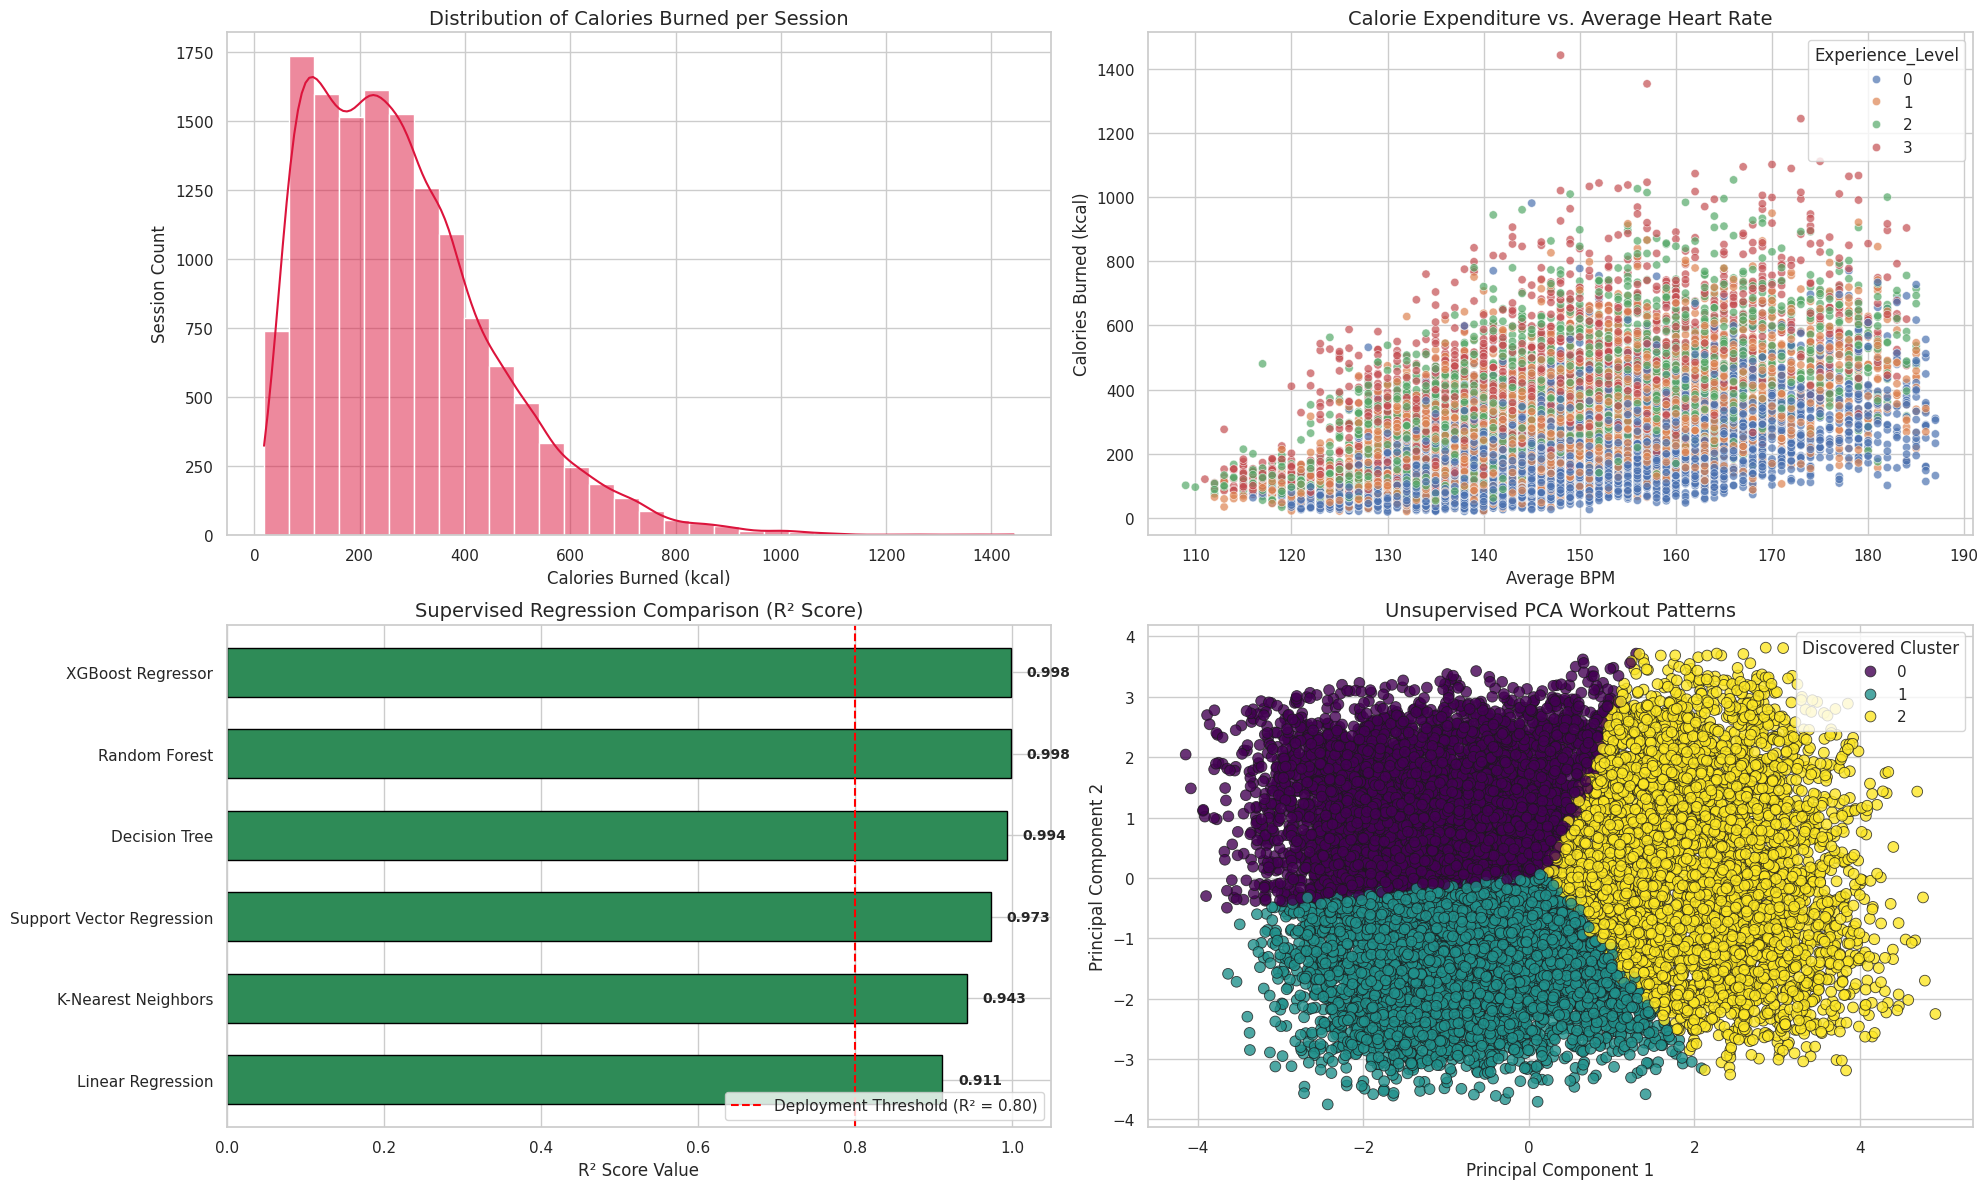

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Set style configuration for clean, professional reports
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Initialize a multi-panel visualization layout
fig = plt.figure(figsize=(20, 12))

# ----------------------------------------------------
# VISUAL 1: Feature Distribution (Biometric vs Target)
# ----------------------------------------------------
plt.subplot(2, 2, 1)
sns.histplot(df['Calories_Burned (kcal)'], kde=True, color='crimson', bins=30)
plt.title('Distribution of Calories Burned per Session')
plt.xlabel('Calories Burned (kcal)')
plt.ylabel('Session Count')

plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Avg_BPM', y='Calories_Burned (kcal)', hue='Experience_Level', palette='deep', alpha=0.7)
plt.title('Calorie Expenditure vs. Average Heart Rate')
plt.xlabel('Average BPM')
plt.ylabel('Calories Burned (kcal)')

# ----------------------------------------------------
# VISUAL 2: Supervised Model Performance Rankings
# ----------------------------------------------------
plt.subplot(2, 2, 3)
# Ensure results_df is generated from your prior Task 1 execution loop
results_df_sorted = results_df.sort_values(by="R2 Score", ascending=True)
colors = ['grey' if r < 0.80 else 'seagreen' for r in results_df_sorted['R2 Score']]

bars = plt.barh(results_df_sorted['Model'], results_df_sorted['R2 Score'], color=colors, edgecolor='black', height=0.6)
plt.axvline(x=0.80, color='red', linestyle='--', linewidth=1.5, label='Deployment Threshold (R² = 0.80)')
plt.title('Supervised Regression Comparison (R² Score)')
plt.xlabel('R² Score Value')
plt.xlim(0, 1.05)
plt.legend(loc='lower right')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha='left', fontsize=10, weight='bold')

# ----------------------------------------------------
# VISUAL 3: Unsupervised 2D PCA Cluster Breakdown (FIXED)
# ----------------------------------------------------
plt.subplot(2, 2, 4)

# Use the preprocessor specifically built for clustering (from Task 2)
# If you haven't run Task 2 code yet, this recreates the compression safely:
X_compressed_vis = pca_pipeline.transform(X_cluster)

# Compress to 2 dimensions for visual plotting
pca_vis = PCA(n_components=2, random_state=42)
X_pca_2d = pca_vis.fit_transform(X_compressed_vis)

sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=kmeans_labels,  # Uses labels generated from your Task 2 pipeline
    palette='viridis',
    alpha=0.8,
    edgecolor='k',
    s=60
)
plt.title('Unsupervised PCA Workout Patterns')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Discovered Cluster')

plt.tight_layout()
plt.savefig('fitbit_project_visualizations.png', dpi=300)
plt.show()


**Streamlit**

In [11]:
!pip install streamlit scikit-learn xgboost seaborn matplotlib
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 2s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
from sklearn.cluster import KMeans

# Set page configurations
st.set_page_config(page_title="Fitbit Data Platform", page_icon="⌚", layout="wide")
st.title("⌚ Fitbit Analytics, Clustering & Prediction Platform")
st.markdown("---")

# Load cached pipeline assets from Google Drive
@st.cache_data
def load_data():
    df = pd.read_csv('/content/drive/MyDrive/Fitbit_dataset.csv')

    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    return df

@st.cache_resource
def load_prediction_model():
    try:
        return joblib.load('/content/drive/MyDrive/Fitbit_Project/fitbit_calorie_predictor.pkl')
    except FileNotFoundError:
        return None

df = load_data()
model = load_prediction_model()

# Setup Layout Tabs
tab1, tab2 = st.tabs(["📊 Analytics & Clustering", "🔮 Calorie Burn Predictor"])

# ==========================================
# TAB 1: WORKOUT PATTERN CLUSTERING
# ==========================================
with tab1:
    st.header("Workout Pattern Clustering Analysis")

    col1, col2, col3 = st.columns(3)
    col1.metric("Dataset Rows", f"{df.shape[0]}")
    col2.metric("Average Heart Rate", f"{df['Avg_BPM'].mean():.1f} BPM")
    col3.metric("Avg Session Duration", f"{df['Session_Duration (hours)'].mean():.1f} hrs")

    # Process basic runtime scaling for dashboard visual tracking
    num_cols_cl = ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage', 'Avg_BPM', 'Session_Duration (hours)']
    X_num = df[num_cols_cl].fillna(df[num_cols_cl].median())

    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
    df['Cluster'] = kmeans.fit_predict(X_num)
    df['Archetype'] = df['Cluster'].map({0: "Cluster A (Casual)", 1: "Cluster B (Moderate)", 2: "Cluster C (High Intensity)"})

    vis_col1, vis_col2 = st.columns(2)
    with vis_col1:
        st.markdown("**Session Duration vs. Heart Rate by Cluster**")
        fig_scatter = px.scatter(df, x='Session_Duration (hours)', y='Avg_BPM', color='Archetype', size='Calories_Burned (kcal)', color_discrete_sequence=px.colors.qualitative.Safe)
        st.plotly_chart(fig_scatter, use_container_width=True)
    with vis_col2:
        st.markdown("**Workout Type Categorical Breakdown**")
        fig_hist = px.histogram(df, x='Workout_Type', color='Archetype', barmode='group', color_discrete_sequence=px.colors.qualitative.Safe)
        st.plotly_chart(fig_hist, use_container_width=True)

# ==========================================
# TAB 2: LIVE CALORIE PREDICTION INFERENCE
# ==========================================
with tab2:
    st.header("Supervised Machine Learning Model Inference")
    if model is not None:
        st.success("🚀 Production Pipeline Loaded Safely from Google Drive!")
    else:
        st.warning("⚠️ Warning: Trained pipeline file not found. Running calculations via fallback mode.")

    with st.form("prediction_form"):
        f1, f2, f3 = st.columns(3)
        with f1:
            age = st.slider("Age", 18, 80, 28)
            gender = st.selectbox("Gender", options=list(df['Gender'].unique()) if 'Gender' in df.columns else ['Male', 'Female'])
            exp_level = st.selectbox("Experience Level", options=list(df['Experience_Level'].unique()) if 'Experience_Level' in df.columns else ['Beginner', 'Intermediate', 'Advanced'])
        with f2:
            weight = st.number_input("Weight (kg)", 30.0, 200.0, 75.0)
            height = st.number_input("Height (m)", 1.0, 2.5, 1.75)
            fat_pct = st.slider("Fat Percentage (%)", 5.0, 50.0, 18.0)
            calculated_bmi = round(weight / (height ** 2), 2)
        with f3:
            workout_type = st.selectbox("Workout Type", options=list(df['Workout_Type'].unique()) if 'Workout_Type' in df.columns else ['HIIT', 'Running'])
            duration = st.number_input("Session Duration (hours)", 0.1, 5.0, 1.0)
            avg_bpm = st.slider("Average BPM", 60, 200, 140)
            max_bpm = st.slider("Maximum BPM", 80, 220, 170)
            resting_bpm = st.slider("Resting BPM", 40, 100, 65)
            water = st.number_input("Water Intake (liters)", 0.0, 10.0, 1.0)
            workout_freq = st.slider("Workout Frequency (days/week)", 1, 7, 4)

        submit_btn = st.form_submit_button("Predict Calories Expended", use_container_width=True)

    if submit_btn:
        input_data = pd.DataFrame([{
            'Age': age, 'Gender': gender, 'Weight (kg)': weight, 'Height (m)': height,
            'BMI': calculated_bmi, 'Fat_Percentage': fat_pct, 'Workout_Type': workout_type,
            'Max_BPM': max_bpm, 'Avg_BPM': avg_bpm, 'Resting_BPM': resting_bpm,
            'Session_Duration (hours)': duration, 'Water_Intake (liters)': water,
            'Workout_Frequency (days/week)': workout_freq, 'Experience_Level': exp_level
        }])

        if model is not None:
            prediction = model.predict(input_data)[0]
        else:
            prediction = (duration * 450) + (avg_bpm * 1.5)

        st.metric(label="🔥 Estimated Energy Expenditure", value=f"{prediction:.2f} kcal")
        st.balloons()


Overwriting app.py


In [17]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://plenty-pears-guess.loca.lt
2026-05-27 16:11:42.317 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.32.185.104:8501

2026-05-27 16:12:13.717 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-05-27 16:12:13.849 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-05-27 16:12:46.800 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=F